# MEMD Filter Banks (MEMDFBs)

Koh, Mandic & Constantinides (2014) treat **MEMD as a digital filter bank**:
each sifting step splits a multivariate record into a high-frequency **IMF** and
a low-frequency **residue**, exactly as a two-channel analysis bank splits a
signal into high-pass and low-pass subbands. Repeating the split on a binary
tree yields **MEMD packets** (any band, not only the octave tree of classical
MEMD). The paper introduces two realisations:

| | **Undecimated MEMDFB** | **Decimated MEMDFB** |
|---|---|---|
| Downsampling | none (every node has length \(T\)) | factor 2 at every stage |
| Tree | octave tree \(\equiv\) ordinary MEMD; full binary tree is possible but redundant | **any** binary tree (nonuniform bands) |
| Reconstruction | sum the node signals | even/odd interpolation + an error branch \(\Delta\) (Theorem / Corollary 1) |
| Length | \(K\) IMFs \(\times\, T\) | about \(1.5\times\) per stage, but shorter nodes; better DRR than storing every IMF at full length |

Classical wavelet / STFT banks use **fixed** LTI filters and therefore a fixed
time–frequency tiling. MEMDFBs inherit MEMD’s data-driven envelopes: there is
no FIR/IIR prototype, no group delay, and the cut-offs adapt to the record.
Because MEMD has **mode alignment**, every channel of a node occupies the same
scale — something independent per-channel EMD cannot guarantee.

PySDKit already implements the inner MEMD engine (`pysdkit.MEMD`). This
notebook builds the filter-bank **around** that engine: one-level IMF/residue
splits, an undecimated octave / binary tree, and a decimated analysis–synthesis
pair with perfect reconstruction.

**Reference**

> M.-S. Koh, D. P. Mandic, A. G. Constantinides.
> *Theory of digital filter banks realized via multivariate empirical mode decomposition.*
> Advances in Adaptive Data Analysis **6**(1), 1450001 (2014).
> https://doi.org/10.1142/S1793536914500010


## 1. What the paper actually does

### 1.1 Why filter banks from MEMD?

Standard MEMD (Rehman & Mandic, 2010) already behaves like a **dyadic filter
bank** on broadband noise: IMF 1 collects the highest-frequency common scale,
IMF 2 the next octave, and so on (Rehman & Mandic, 2011). Two limitations remain:

1. **Fixed octave tree.** Only the residue is sifted again, so an IMF that still
   contains two tones cannot be split further (mode mixing stays inside that IMF).
2. **No downsampling.** Every IMF has the original length \(T\), which is
   wasteful once the band is known to be coarse.

The 2014 paper lifts both restrictions by copying the even/odd construction
previously given for univariate EMD filter banks (Koh & Rodriguez-Marek, 2013).

### 1.2 Undecimated MEMDFBs (paper §3)

At every node \(X_{i,j}\) run **one** MEMD split:

\[
X_{i,j} = \underbrace{X_{i+1,\,2j}}_{\text{residue (low)}}
         + \underbrace{X_{i+1,\,2j+1}}_{\text{first IMF (high)}}.
\]

No samples are discarded. For an **octave** tree (always split the residue,
never the IMF) the end-nodes are exactly the IMFs of a single full MEMD run
(paper Fig. 2). A **full binary** tree also splits IMFs, producing an MEMD
packet with more flexible bands; because there is no downsampling this packet
is linearly dependent (the extra nodes mostly reproduce their parent IMF).

### 1.3 Decimated MEMDFBs (paper §4)

Downsampling a data-driven IMF with a naive \(\downarrow 2\) aliases, because
MEMD is not a QMF. The paper therefore keeps **three** length-\(T/2\)
multivariate streams at each stage (Fig. 4):

- \(X_{i+1,2j}\) — odd-indexed residue (or, equivalently, the residue of the
  odd-indexed parent);
- \(X_{i+1,2j+1}\) — odd-indexed IMF;
- \(\Delta_{i+1,j}\) — interpolation error on the **even** grid.

The even samples of the parent are predicted by interpolating the odd IMF and
odd residue with the **same** interpolator used at synthesis; \(\Delta\) stores
whatever the interpolator cannot predict. Corollary 1: if analysis and synthesis
share that interpolator, the bank has **perfect reconstruction and aliasing
cancellation** for an arbitrary tree. Synthesis (Fig. 6) is the reverse:
interpolate the odd branches, add \(\Delta\), interleave even/odd.

### 1.4 Noise-aided MEMD (NA-MEMD)

When a record has too few extrema, the paper (following Rehman et al., 2013)
appends 2–3 **auxiliary Gaussian-noise channels**, runs MEMD on the stacked
signal, then discards the noise IMFs. Noise is **not** added onto the data
themselves (unlike EEMD), so a single realisation already reconstructs.

### 1.5 Applications in the paper (§5)

Stereo / multi-microphone speech, audio, and image (row-wise multivariate)
examples; arbitrary trees give nonuniform bands (formants, edges) without
redesigning filters. A data-reduction ratio versus storing every full-length
MEMD IMF is also derived.

The remainder of this notebook implements the 1-D multivariate case with
`pysdkit.MEMD`.


## 2. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from pysdkit import MEMD
from pysdkit.data import load_memd_syn_hex

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(MEMD())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Multivariate Empirical Mode Decomposition (MEMD)


## 3. One MEMD split = one two-channel analysis stage

A filter-bank stage only needs the **first IMF** and the residue
\(x - \mathrm{IMF}_1\). That is identical to stopping MEMD after a single
sifting loop; we still call the existing `MEMD.fit_transform` and peel off
slice 0 (the engine always returns every IMF plus the residue).


In [2]:
MEMD_KW = dict(n_dir=16, max_iter=80)


def memd_split(x: np.ndarray, **kwargs) -> tuple[np.ndarray, np.ndarray]:
    """One analysis stage: first IMF (high) and residue (low).

    Parameters
    ----------
    x : ndarray, shape (n_channels, n_samples)
        Parent node. ``3 <= n_channels <= 16``.

    Returns
    -------
    imf : ndarray, shape (n_channels, n_samples)
        First multivariate IMF (high-pass node \(X_{i+1, 2j+1}\)).
    residue : ndarray, shape (n_channels, n_samples)
        \(x - \mathrm{imf}\) (low-pass node \(X_{i+1, 2j}\)).
    """
    kw = {**MEMD_KW, **kwargs}
    imfs = MEMD(**kw).fit_transform(x)  # (K, T, C)
    imf = np.asarray(imfs[0].T, dtype=float)  # (C, T)
    residue = np.asarray(x, dtype=float) - imf
    return imf, residue


def _tones(n: int = 400, fs: float = 200.0) -> tuple[np.ndarray, np.ndarray]:
    """Three-channel mixture with a shared 4 Hz tone (mode alignment)."""
    t = np.arange(n) / fs
    ch0 = np.cos(2 * np.pi * 4 * t) + 0.55 * np.cos(2 * np.pi * 18 * t)
    ch1 = np.cos(2 * np.pi * 4 * t) + 0.45 * np.sin(2 * np.pi * 11 * t)
    ch2 = 0.35 * np.cos(2 * np.pi * 4 * t) + 0.8 * np.cos(2 * np.pi * 18 * t)
    return t, np.vstack([ch0, ch1, ch2])


t, x = _tones()
imf_h, res_l = memd_split(x)
print("input", x.shape, "IMF", imf_h.shape, "residue", res_l.shape)
print("split reconstruction |error|", np.max(np.abs(imf_h + res_l - x)))

input (3, 400) IMF (3, 400) residue (3, 400)
split reconstruction |error| 2.220446049250313e-16


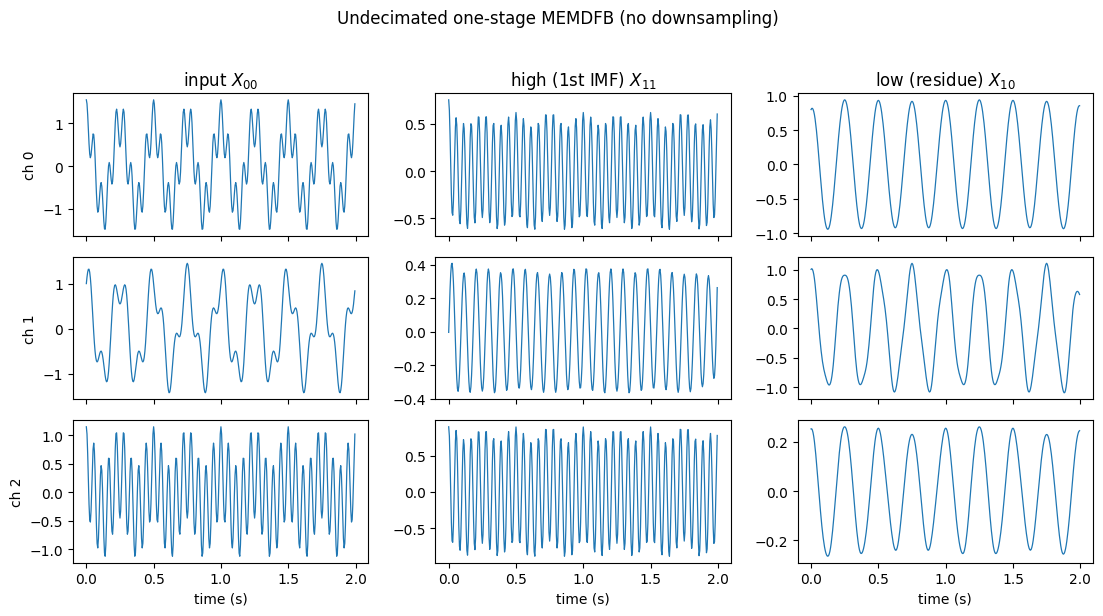

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(11, 6), sharex=True)
titles = ["input $X_{00}$", "high (1st IMF) $X_{11}$", "low (residue) $X_{10}$"]
stacks = [x, imf_h, res_l]
for col, (title, sig) in enumerate(zip(titles, stacks)):
    axes[0, col].set_title(title)
    for c in range(3):
        axes[c, col].plot(t, sig[c], lw=0.9)
        if col == 0:
            axes[c, col].set_ylabel(f"ch {c}")
        if c == 2:
            axes[c, col].set_xlabel("time (s)")
fig.suptitle("Undecimated one-stage MEMDFB (no downsampling)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Undecimated octave tree \equiv full MEMD

Paper §3: if we always split the **residue** and never the IMF, node
\((1,1)\) is IMF 1, \((2,1)\) is IMF 2, \((2,0)\) is the final residue —
the same tiling as one call to `MEMD.fit_transform`. The next cell checks
that numerically (small differences can appear because each split restarts
sifting on the current residue rather than continuing the original loop).


In [4]:
def undecimated_octave(x: np.ndarray, depth: int, **kwargs):
    """Octave MEMDFB: return [IMF1, IMF2, ..., IMFdepth, residue]."""
    nodes = []
    current = np.asarray(x, dtype=float)
    for _ in range(depth):
        imf, current = memd_split(current, **kwargs)
        nodes.append(imf)
    nodes.append(current)
    return nodes


depth = 3
octave = undecimated_octave(x, depth=depth)
full = MEMD(**MEMD_KW).fit_transform(x)
print("octave nodes", len(octave), "shapes", [n.shape for n in octave])
print("full MEMD IMFs", full.shape)

# Compare first IMF of both constructions
err_imf1 = np.max(np.abs(octave[0] - full[0].T))
print("max |octave IMF1 - MEMD IMF1|", err_imf1)
print("octave sum |error| vs x", np.max(np.abs(sum(octave) - x)))

octave nodes 4 shapes [(3, 400), (3, 400), (3, 400), (3, 400)]
full MEMD IMFs (4, 400, 3)
max |octave IMF1 - MEMD IMF1| 0.0
octave sum |error| vs x 2.220446049250313e-16


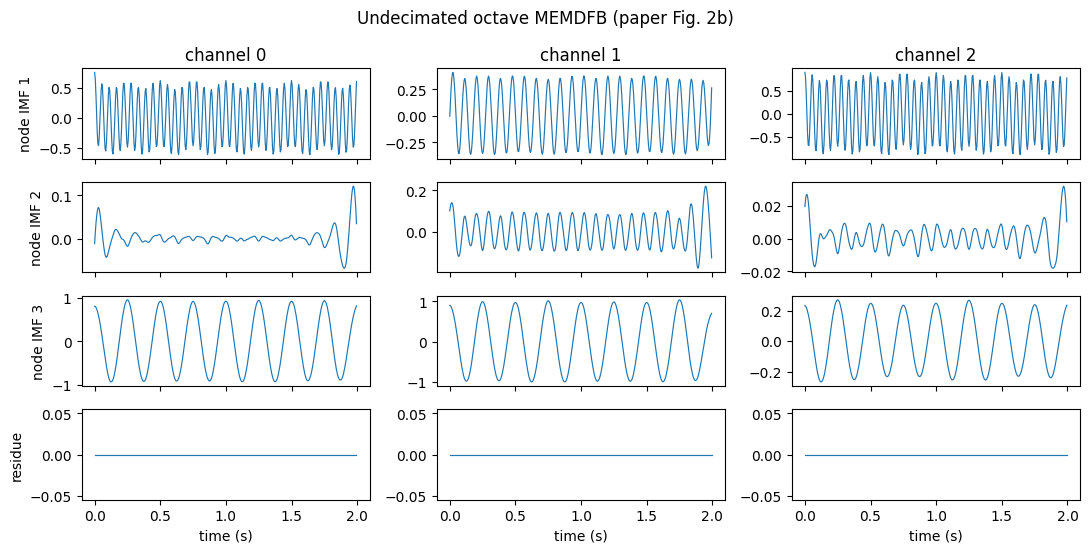

In [5]:
n_plot = min(len(octave), 4)
fig, axes = plt.subplots(n_plot, 3, figsize=(11, 1.4 * n_plot), sharex=True)
for k in range(n_plot):
    for c in range(3):
        axes[k, c].plot(t, octave[k][c], lw=0.85)
        if k == 0:
            axes[k, c].set_title(f"channel {c}")
        if c == 0:
            ylab = "residue" if k == len(octave) - 1 else f"node IMF {k + 1}"
            if k == n_plot - 1 and k < len(octave) - 1:
                ylab = f"IMF {k + 1}"
            axes[k, c].set_ylabel(ylab)
        if k == n_plot - 1:
            axes[k, c].set_xlabel("time (s)")
fig.suptitle("Undecimated octave MEMDFB (paper Fig. 2b)")
plt.tight_layout()
plt.show()

A **full binary** undecimated tree also splits the IMF branch. That is the
MEMD-packet idea: any node can be a parent. Without downsampling the children
of an IMF node are often “IMF \(\approx\) parent, residue \(\approx 0\)”
because of MEMD’s mode-splitting (paper §3). The construction is still useful
as a template for the **decimated** packet in the next section.


In [6]:
def undecimated_full_binary(x: np.ndarray, depth: int, **kwargs):
    """Full binary tree. nodes[(i, j)] has length T at every level i."""
    nodes = {(0, 0): np.asarray(x, dtype=float)}
    for i in range(depth):
        for j in range(2**i):
            parent = nodes[(i, j)]
            imf, res = memd_split(parent, **kwargs)
            nodes[(i + 1, 2 * j)] = res
            nodes[(i + 1, 2 * j + 1)] = imf
    return nodes


tree = undecimated_full_binary(x, depth=2)
print("nodes", sorted(tree))
# Root is the sum of the two children at level 1
print(
    "level-1 PR |error|",
    np.max(np.abs(tree[(1, 0)] + tree[(1, 1)] - tree[(0, 0)])),
)

nodes [(0, 0), (1, 0), (1, 1), (2, 0), (2, 1), (2, 2), (2, 3)]
level-1 PR |error| 2.220446049250313e-16


## 5. Decimated MEMDFB: even / odd analysis and synthesis

Naive \(\downarrow 2\) after MEMD aliases because the IMF is not a QMF
half-band filter. Following Koh et al. (Figs. 4 and 6) we instead:

1. Split the parent into **odd-** and **even-indexed** samples.
2. Run one MEMD split on the **odd** stream (length \(T/2\)).
3. Predict the even stream by interpolating the odd IMF and odd residue
   (cubic spline; any affine interpolator works — Theorem 1 only requires
   analysis and synthesis to share it).
4. Store the prediction error \(\Delta = X_{\mathrm{even}} - \widehat{X}_{\mathrm{even}}\).

Synthesis interpolates the odd branches with the same spline, adds \(\Delta\),
and interleaves. This is Corollary 1: **perfect reconstruction with aliasing
cancelled**, for any tree.


In [7]:
def _even_odd(x: np.ndarray):
    """x: (C, T) with T even -> even samples, odd samples."""
    x = np.asarray(x, dtype=float)
    if x.shape[1] % 2:
        x = x[:, :-1]
    return x[:, 0::2], x[:, 1::2]


def _interleave(even: np.ndarray, odd: np.ndarray) -> np.ndarray:
    c, n_half = even.shape
    y = np.empty((c, n_half * 2), dtype=float)
    y[:, 0::2] = even
    y[:, 1::2] = odd
    return y


def interpolate_odd_to_even(odd: np.ndarray) -> np.ndarray:
    """Cubic spline: values on t=1,3,... -> values on t=0,2,..."""
    n_half = odd.shape[1]
    t_odd = np.arange(n_half, dtype=float) * 2.0 + 1.0
    t_even = np.arange(n_half, dtype=float) * 2.0
    even = np.empty_like(odd, dtype=float)
    for c in range(odd.shape[0]):
        even[c] = CubicSpline(t_odd, odd[c], bc_type="natural", extrapolate=True)(
            t_even
        )
    return even


def analysis_stage(x: np.ndarray, **kwargs):
    """One decimated analysis stage (paper Fig. 4).

    Returns
    -------
    res_odd : ndarray (C, T/2)
        Odd-indexed residue \(X_{i+1, 2j}\).
    delta : ndarray (C, T/2)
        Even-grid interpolation error \(\Delta_{i+1, j}\).
    imf_odd : ndarray (C, T/2)
        Odd-indexed first IMF \(X_{i+1, 2j+1}\).
    """
    x_even, x_odd = _even_odd(x)
    imf_odd, res_odd = memd_split(x_odd, **kwargs)
    x_even_hat = interpolate_odd_to_even(imf_odd) + interpolate_odd_to_even(res_odd)
    delta = x_even - x_even_hat
    return res_odd, delta, imf_odd


def synthesis_stage(
    res_odd: np.ndarray, delta: np.ndarray, imf_odd: np.ndarray
) -> np.ndarray:
    """One decimated synthesis stage (paper Fig. 6)."""
    x_odd = imf_odd + res_odd
    x_even_hat = interpolate_odd_to_even(imf_odd) + interpolate_odd_to_even(res_odd)
    x_even = x_even_hat + delta
    return _interleave(x_even, x_odd)

parent (3, 400)
res_odd (3, 200) delta (3, 200) imf_odd (3, 200)
perfect reconstruction max |error| 2.220446049250313e-16


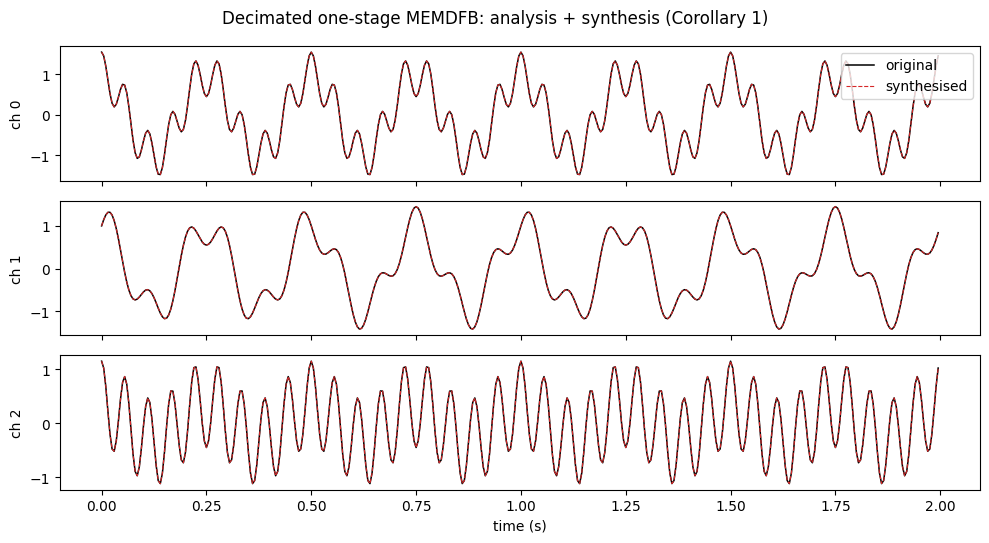

In [8]:
# Crop to even length
x_even_len = x[:, : x.shape[1] - x.shape[1] % 2]
res_odd, delta, imf_odd = analysis_stage(x_even_len)
x_hat = synthesis_stage(res_odd, delta, imf_odd)

print("parent", x_even_len.shape)
print("res_odd", res_odd.shape, "delta", delta.shape, "imf_odd", imf_odd.shape)
print("perfect reconstruction max |error|", np.max(np.abs(x_hat - x_even_len)))

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True)
tt = t[: x_even_len.shape[1]]
for c, ax in enumerate(axes):
    ax.plot(tt, x_even_len[c], color="k", lw=1.1, label="original" if c == 0 else None)
    ax.plot(
        tt,
        x_hat[c],
        color="C3",
        lw=0.8,
        ls="--",
        label="synthesised" if c == 0 else None,
    )
    ax.set_ylabel(f"ch {c}")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle("Decimated one-stage MEMDFB: analysis + synthesis (Corollary 1)")
plt.tight_layout()
plt.show()

### 5.1 A depth-2 decimated packet

Each low child \((i+1, 2j)\) and each high child \((i+1, 2j+1)\) can be split
again. Every stage stores its own \(\Delta\). Synthesis walks the tree from the
leaves back to the root. This is the **MEMD packet** of the paper: the tree
need not be octave, so the bands are no longer forced to be dyadic.


In [9]:
def decimated_depth2(x: np.ndarray, **kwargs):
    """Full binary decimated tree of depth 2, plus all error nodes."""
    r10, d00, h11 = analysis_stage(x, **kwargs)  # level 1
    r20, d10, h21 = analysis_stage(r10, **kwargs)  # split low
    r22, d11, h23 = analysis_stage(h11, **kwargs)  # split high
    return {
        "X20": r20,
        "X21": h21,
        "D10": d10,
        "X22": r22,
        "X23": h23,
        "D11": d11,
        "D00": d00,
    }


def synthesise_depth2(nodes: dict) -> np.ndarray:
    low = synthesis_stage(nodes["X20"], nodes["D10"], nodes["X21"])
    high = synthesis_stage(nodes["X22"], nodes["D11"], nodes["X23"])
    return synthesis_stage(low, nodes["D00"], high)


pkt = decimated_depth2(x_even_len)
x_pkt = synthesise_depth2(pkt)
print({k: v.shape for k, v in pkt.items()})
print("depth-2 packet PR max |error|", np.max(np.abs(x_pkt - x_even_len)))

{'X20': (3, 100), 'X21': (3, 100), 'D10': (3, 100), 'X22': (3, 100), 'X23': (3, 100), 'D11': (3, 100), 'D00': (3, 200)}
depth-2 packet PR max |error| 2.220446049250313e-16


## 6. Dyadic filter-bank spectra (related MEMD property)

Rehman & Mandic (2011), cited in the 2014 paper, showed that MEMD applied to
multichannel white noise yields IMF spectra that tile frequency like a
**wavelet octave bank**. MATLAB `filt_bank.m` plots that picture. We reproduce
it here with a short 3-channel WGN record (the toolbox demo uses 8 channels of
length 5000; a smaller draw already shows the nested bands).


WGN IMFs (11, 1024, 3)


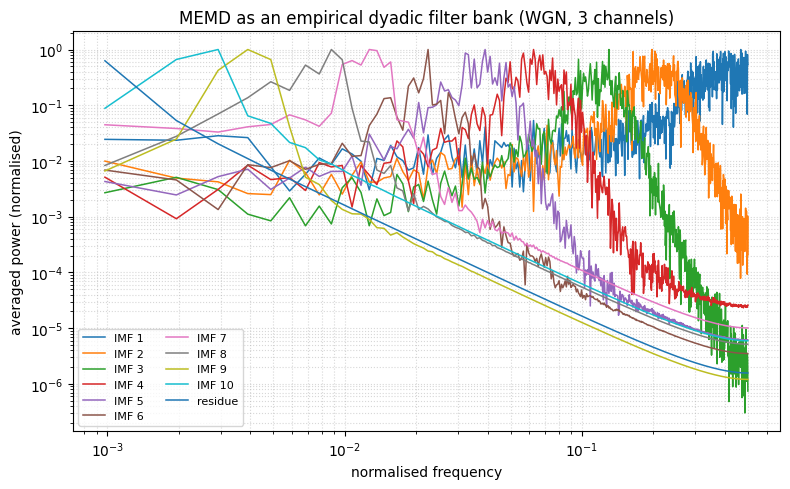

In [10]:
rng = np.random.default_rng(0)
n_wgn, n_ch = 1024, 3
wgn = rng.standard_normal((n_ch, n_wgn))
imf_wgn = MEMD(n_dir=16, max_iter=60).fit_transform(wgn)  # (K, T, C)
print("WGN IMFs", imf_wgn.shape)

# Periodogram per IMF, averaged across channels, positive frequencies
freqs = np.fft.rfftfreq(n_wgn, d=1.0)
fig, ax = plt.subplots(figsize=(8, 5))
for k in range(imf_wgn.shape[0]):
    spec = np.mean(np.abs(np.fft.rfft(imf_wgn[k], axis=0)) ** 2, axis=1)
    spec = spec / spec.max()
    label = "residue" if k == imf_wgn.shape[0] - 1 else f"IMF {k + 1}"
    ax.loglog(freqs[1:], spec[1:], lw=1.1, label=label)
ax.set_xlabel("normalised frequency")
ax.set_ylabel("averaged power (normalised)")
ax.set_title("MEMD as an empirical dyadic filter bank (WGN, 3 channels)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 7. NA-MEMD (optional noise channels)

If a record is poorly sampled, append \(N_{\sigma}\) Gaussian channels, run
MEMD, then drop those channels from every IMF. Reconstruction of the original
channels is still the sum along the IMF axis.


In [11]:
def na_memd(
    x: np.ndarray, n_noise: int = 2, noise_std: float = 0.2, seed: int = 0, **kwargs
):
    """Noise-aided MEMD (Rehman et al., 2013 / Koh et al., 2014 §2)."""
    rng = np.random.default_rng(seed)
    noise = noise_std * rng.standard_normal((n_noise, x.shape[1]))
    stacked = np.vstack([x, noise])
    imfs = MEMD(**{**MEMD_KW, **kwargs}).fit_transform(stacked)  # (K, T, C+n_noise)
    return imfs[:, :, : x.shape[0]]


na_imfs = na_memd(x, n_noise=2)
print("NA-MEMD IMFs", na_imfs.shape)
print("NA reconstruction max |error|", np.max(np.abs(na_imfs.sum(axis=0).T - x)))

NA-MEMD IMFs (9, 400, 3)
NA reconstruction max |error| 6.661338147750939e-16


## 8. MATLAB hexavariate demo as a filter bank

`syn_hex_inp.mat` is the six-channel synthetic used in the original MEMD paper.
An undecimated octave MEMDFB of depth 3 is just a convenient way to stop after
three high-pass nodes plus a residue — useful when only a few bands are needed
for denoising or fusion (keep IMF 1 as “noise”, sum the rest as the trend).


hex snippet (6, 400)


nodes [(6, 400), (6, 400), (6, 400), (6, 400)]
recon max |error| 8.881784197001252e-16


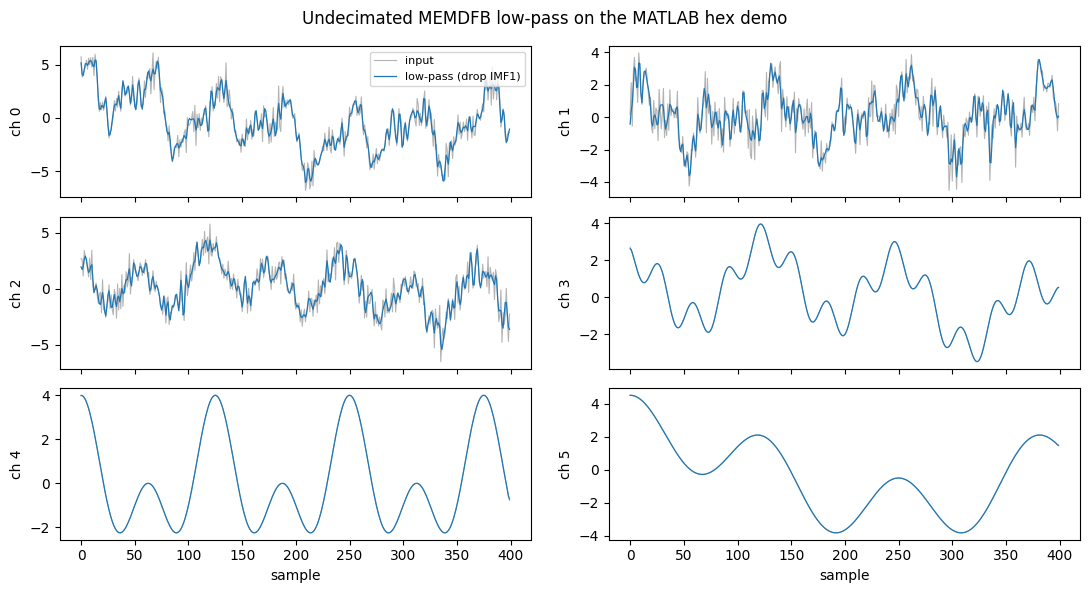

In [12]:
hex_sig = load_memd_syn_hex()["signal"][:, :400]  # (6, 400)
hex_t = np.arange(hex_sig.shape[1])
print("hex snippet", hex_sig.shape)

hex_nodes = undecimated_octave(hex_sig, depth=3, n_dir=16, max_iter=80)
print("nodes", [n.shape for n in hex_nodes])
print("recon max |error|", np.max(np.abs(sum(hex_nodes) - hex_sig)))

# Simple data-driven low-pass: drop the first (highest-frequency) node
hex_lp = sum(hex_nodes[1:])
fig, axes = plt.subplots(3, 2, figsize=(11, 6), sharex=True)
axes = axes.ravel()
for c in range(6):
    axes[c].plot(
        hex_t, hex_sig[c], color="0.7", lw=0.8, label="input" if c == 0 else None
    )
    axes[c].plot(
        hex_t,
        hex_lp[c],
        color="C0",
        lw=0.9,
        label="low-pass (drop IMF1)" if c == 0 else None,
    )
    axes[c].set_ylabel(f"ch {c}")
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("sample")
axes[-2].set_xlabel("sample")
fig.suptitle("Undecimated MEMDFB low-pass on the MATLAB hex demo")
plt.tight_layout()
plt.show()

## 9. Take-aways

- **MEMD** already *is* a two-channel analysis bank (IMF = high, residue = low)
  with data-driven cut-offs and mode alignment across channels.
- **Undecimated MEMDFBs** replay that split on a tree. An octave tree
  reproduces ordinary MEMD; a full tree is an MEMD packet.
- **Decimated MEMDFBs** add even/odd interpolation and an error node \(\Delta\)
  so that \(\downarrow 2\) does not destroy perfect reconstruction (Corollary 1).
  Any binary tree is then legal, which is the main practical gain over MEMD.
- Implementation in this notebook is a thin wrapper around `pysdkit.MEMD`:
  `memd_split`, `analysis_stage` / `synthesis_stage`, and the two tree walkers.

Related PySDKit notebooks: `examples/memd/memd.ipynb` (MEMD engine and
Hammersley directions), `examples/image/bmemd.ipynb` (2-D multivariate EMD).
